# SPIN — Example 1: the closed-form spiral

This notebook reproduces the **toy spiral example** from the paper (Figs. 2-3),
the cleanest place to *see* what in-span learning does.

**The setup.** A point traces an exact 3-D spiral
$q(t)=[\cos t,\ \sin t,\ \alpha t]$. We build a deliberately minimal **rank-2**
ROM from just two snapshots, so its subspace $\mathcal{S}_0$ is a fixed plane.
The spiral leaves that plane, so the ROM cannot stay accurate forever — it needs
to adapt.

**The two channels.** Before a single external *out-of-span* correction
arrives, the ROM streams a few of its **own** in-span predictions through an
iSVD-with-forgetting. These updates do **not** move the subspace (the
predictions live inside it), but they **rotate and reweight** the basis. We then
apply the *same* correction to:

- the **baseline adaptive ROM** — correction applied to the original spectrum;
- the **SPIN ROM** — correction applied *after* in-span preconditioning.

Because the spiral flow is exact, there is no time-integration error: every
difference comes purely from the in-span preconditioning of the spectrum.


## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))   # use the local `spin` package

import numpy as np
import matplotlib.pyplot as plt

import spin
from spin.plotting import use_paper_style, PALETTE
use_paper_style()
print("spin version:", spin.__version__)

spin version: 0.1.0


## 2 · Control variables

Everything you can play with is here. The defaults reproduce the paper exactly.
Try, for example, a larger `GAMMA_IN` (less forgetting) or more in-span updates
`N_INSPAN` and watch how the reported `capture` / `plane tilt` change.

In [2]:
ALPHA     = 0.4    # spiral vertical rate (q3 = ALPHA * t)
DT        = 0.35   # time step of the exact discrete flow
T0        = 4.0    # start time
GAMMA_IN  = 0.1    # in-span forgetting factor (aggressive -> clear spectral contraction)
N_INSPAN  = 4      # number of in-span updates before the single correction

## 3 · Run the experiment

`build_spiral_experiment` does everything: builds the rank-2 ROM, advances it in
its plane, performs `N_INSPAN` in-span updates, and absorbs one out-of-span
correction with and without that preconditioning. It returns all the quantities
the paper reports.

In [3]:
exp = spin.build_spiral_experiment(alpha=ALPHA, dt=DT, t0=T0,
                                   gamma_in=GAMMA_IN, n_inspan=N_INSPAN)

print(f"initial singular values  Sigma_0      = {exp['Sigma0']}")
print(f"after in-span updates     Sigma_in_pre = {exp['Sigma_in_pre']}")
print("  -> the subspace is unchanged, but the weak mode has been suppressed\n")

for name in ("baseline", "spin"):
    d = exp[name]
    label = {"baseline": "baseline adaptive", "spin": "SPIN"}[name]
    print(f"{label:18s}:  capture = {d['capture']:.2f}   "
          f"plane tilt = {d['plane']:.2f} deg   "
          f"correction error = {d['correction_error']:.2e}")

initial singular values  Sigma_0      = [2.91533718 0.25061752]
after in-span updates     Sigma_in_pre = [2.4760298  0.03093119]
  -> the subspace is unchanged, but the weak mode has been suppressed

baseline adaptive :  capture = 0.26   plane tilt = 15.06 deg   correction error = 1.02e-02
SPIN              :  capture = 0.80   plane tilt = 53.29 deg   correction error = 8.84e-04


The printed numbers match the paper:

| quantity | baseline adaptive | SPIN |
|---|---|---|
| residual capture | **0.26** | **0.80** |
| plane-change angle | **15.06°** | **53.29°** |
| correction error | **1.0e-2** | **8.8e-4** |

In-span preconditioning lets the *same* correction reorient the plane ~3.5×
more and capture ~3× more of the new direction — purely by having reweighted the
spectrum beforehand.

## 4 · The spectral mechanism (Fig. 3c)

Why does it help? The incoming residual competes with the weakest retained mode. In-span learning shrinks that weak mode, so the residual-to-weakest-mode ratio $\eta=\rho^2/\lambda_r$ crosses from $\ll1$ (residual loses) to $>1$ (residual wins a slot).

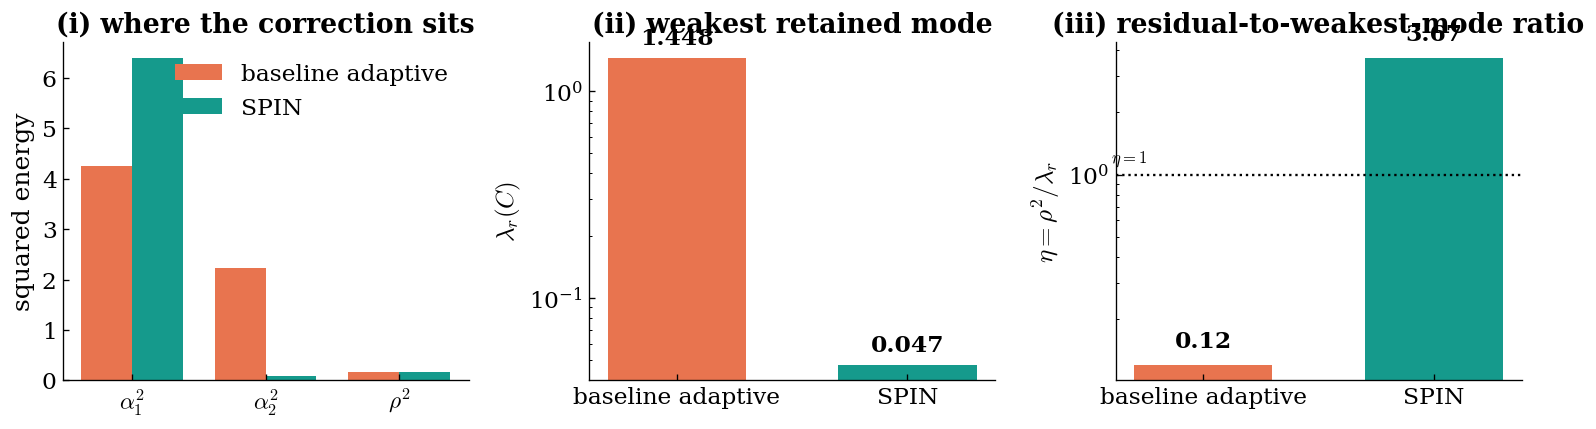

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
cols = [PALETTE["baseline"], PALETTE["spin"]]
names = ["baseline adaptive", "SPIN"]

# (i) where the correction energy sits: alpha_1^2, alpha_2^2, rho^2
ax = axes[0]
out_v = [exp["alpha_out"][0]**2, exp["alpha_out"][1]**2, exp["rho"]**2]
in_v  = [exp["alpha_in"][0]**2,  exp["alpha_in"][1]**2,  exp["rho"]**2]
xp = np.arange(3); w = 0.38
ax.bar(xp - w/2, out_v, w, color=cols[0], label=names[0])
ax.bar(xp + w/2, in_v,  w, color=cols[1], label=names[1])
ax.set_xticks(xp); ax.set_xticklabels([r"$\alpha_1^2$", r"$\alpha_2^2$", r"$\rho^2$"])
ax.set_ylabel("squared energy"); ax.set_title("(i) where the correction sits")
ax.legend()

# (ii) weakest retained mode lambda_r
ax = axes[1]
vals = [exp["lam_out"], exp["lam_in"]]
ax.bar(names, vals, color=cols, width=0.6); ax.set_yscale("log")
for i, v in enumerate(vals):
    ax.text(i, v*1.1, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel(r"$\lambda_r(C)$"); ax.set_title("(ii) weakest retained mode")

# (iii) eta = rho^2 / lambda_r
ax = axes[2]
vals = [exp["eta_out"], exp["eta_in"]]
ax.bar(names, vals, color=cols, width=0.6); ax.set_yscale("log")
ax.axhline(1.0, color="k", ls=":", lw=1.4); ax.text(-0.4, 1.15, r"$\eta=1$", fontsize=10)
for i, v in enumerate(vals):
    ax.text(i, v*1.15, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel(r"$\eta=\rho^2/\lambda_r$"); ax.set_title("(iii) residual-to-weakest-mode ratio")
fig.tight_layout(); plt.show()

## 5 · Spectral diagnostics (Fig. 3d)

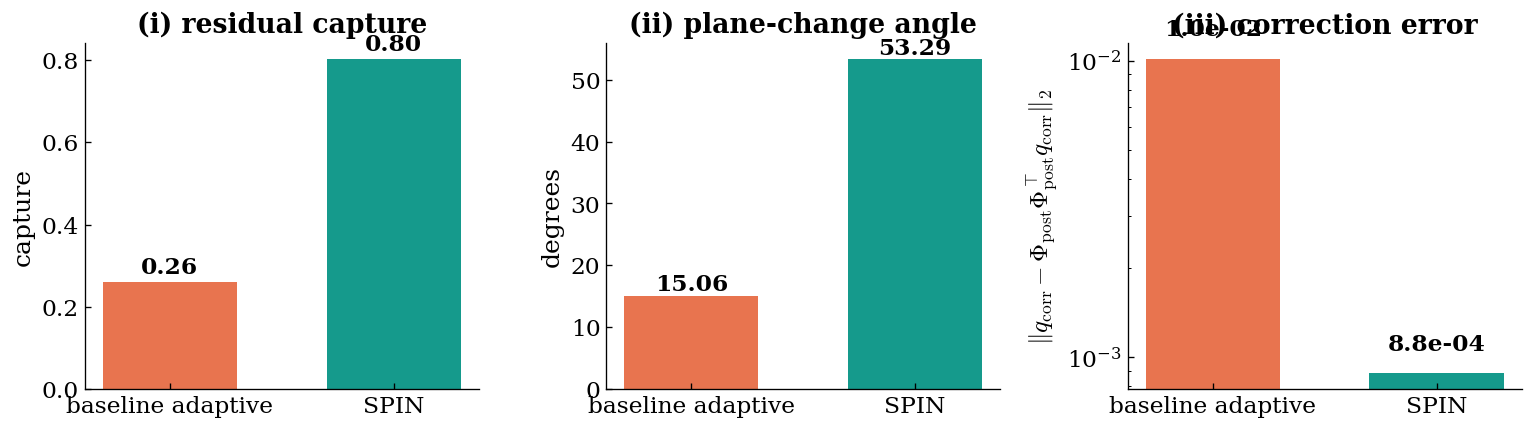

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
b, s = exp["baseline"], exp["spin"]
trip = [("(i) residual capture", "capture", [b["capture"], s["capture"]], "{:.2f}", False),
        ("(ii) plane-change angle", "degrees", [b["plane"], s["plane"]], "{:.2f}", False),
        ("(iii) correction error",
         r"$\|q_{\rm corr}-\Phi_{\rm post}\Phi_{\rm post}^\top q_{\rm corr}\|_2$",
         [b["correction_error"], s["correction_error"]], "{:.1e}", True)]
for ax, (title, ylab, vals, fmt, logy) in zip(axes, trip):
    ax.bar(names, vals, color=cols, width=0.6)
    if logy: ax.set_yscale("log")
    for i, v in enumerate(vals):
        ax.text(i, v*(1.15 if logy else 1.0)+(0 if logy else 0.01),
                fmt.format(v), ha="center", va="bottom", fontweight="bold")
    ax.set_title(title); ax.set_ylabel(ylab)
fig.tight_layout(); plt.show()

## 6 · In-span spectral preconditioning, visualized (Fig. 2b-e)

Each in-span update reshapes the reduced covariance ellipse inside the fixed
plane $\mathcal{S}_0$ (axes along the initial basis $\phi_{0,1},\phi_{0,2}$). The
active direction is reinforced while the unvisited one is suppressed — the
subspace never moves; only its spectrum and orientation do.

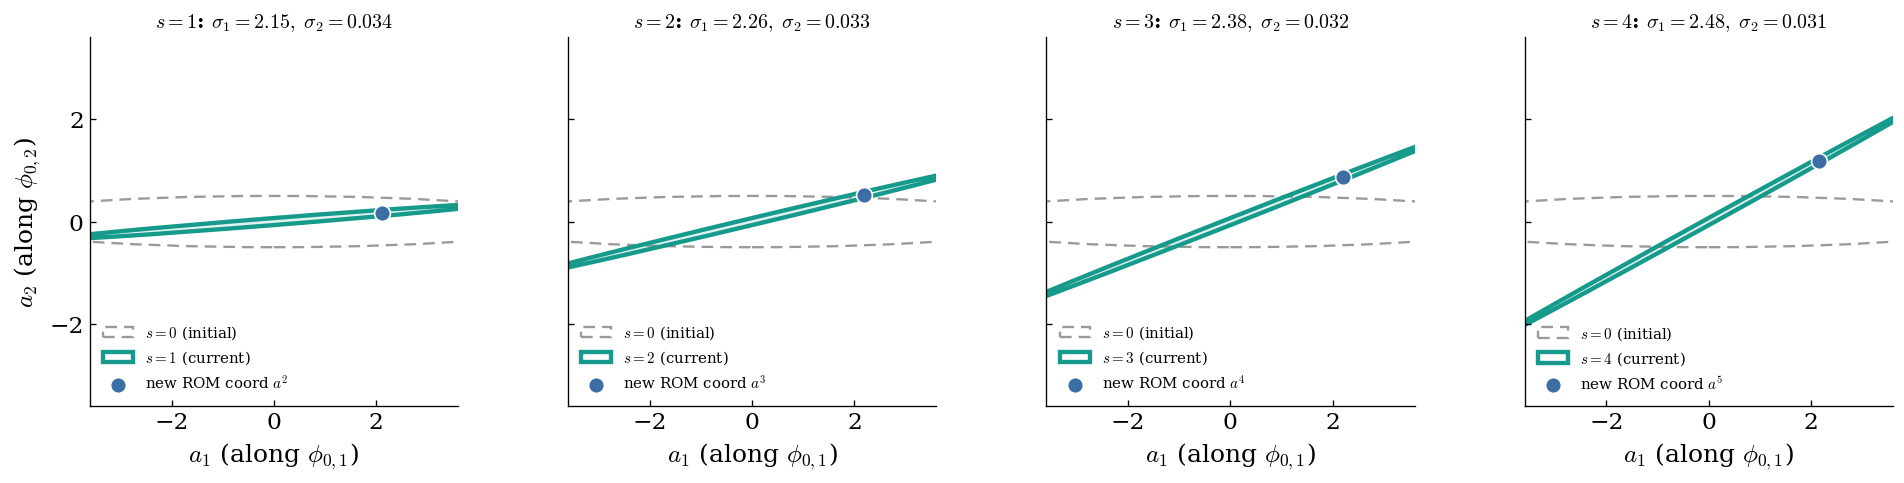

In [6]:
from matplotlib.patches import Ellipse

def ellipse_geom(C):
    lam, V = np.linalg.eigh(C); order = np.argsort(lam)[::-1]
    lam, V = lam[order], V[:, order]
    ang = np.degrees(np.arctan2(V[1, 0], V[0, 0]))
    return ang, 4*np.sqrt(lam[0]), 4*np.sqrt(lam[1])

covs = exp["covs"]; A = np.column_stack([exp["a_ROM"][k] for k in [2, 3, 4, 5]])
fig, axes = plt.subplots(1, N_INSPAN, figsize=(4.2*N_INSPAN, 4.0), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for s_idx, ax in enumerate(axes, start=1):
    a0, w0, h0 = ellipse_geom(covs[0])
    ax.add_patch(Ellipse((0, 0), w0, h0, angle=a0, fill=False, edgecolor=PALETTE["ic"],
                         lw=1.4, ls=(0, (5, 3)), label=r"$s=0$ (initial)"))
    ang, w, h = ellipse_geom(covs[s_idx])
    ax.add_patch(Ellipse((0, 0), w, h, angle=ang, facecolor=PALETTE["spin"], alpha=0.13))
    ax.add_patch(Ellipse((0, 0), w, h, angle=ang, fill=False, edgecolor=PALETTE["spin"],
                         lw=2.6, label=rf"$s={s_idx}$ (current)"))
    ax.scatter(*A[:, s_idx-1], color=PALETTE["corr"], s=90, zorder=5, edgecolor="white",
               label=rf"new ROM coord $a^{{{s_idx+1}}}$")
    sig = exp["spectra"][s_idx]
    ax.set_title(rf"$s={s_idx}$: $\sigma_1={sig[0]:.2f},\ \sigma_2={sig[1]:.3f}$",
                 fontsize=12)
    ax.set_xlim(-3.6, 3.6); ax.set_ylim(-3.6, 3.6); ax.set_aspect("equal")
    ax.set_xlabel(r"$a_1$ (along $\phi_{0,1}$)"); ax.legend(loc="lower left", fontsize=9)
axes[0].set_ylabel(r"$a_2$ (along $\phi_{0,2}$)")
fig.tight_layout(); plt.show()

---
**Takeaway.** In-span learning uses *no new full-order information*. By streaming
the ROM's own predictions through an iSVD with forgetting, it preconditions the
spectrum so the next external correction is absorbed far more effectively. The
nonlinear-PDE notebooks (`02_burgers.ipynb`, `03_fisher_kpp.ipynb`) show the same
mechanism improving long-horizon prediction.